In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os.path
sys.path.append(os.path.dirname(os.path.abspath('')))

import geopandas as gpd
import pandas as pd
import numpy as np
import json

from geo_plotting import map_labels, plot_map
from geo import get_geo_json 

In [2]:
 # Standaard categorieen en bijbehorende kleuren
 cat_map = {
    1: "veel minder dan gemiddeld",
    2: "minder dan gemiddeld",
    3: "rondom het gemiddeld",
    4: "meer dan gemiddeld",
    5: "veel meer dan gemiddeld",
    9: "niet beschikbaar"
}

color_map_blue = {
    "veel minder dan gemiddeld": "#E5F2FC",
    "minder dan gemiddeld": "#B1D9F5",
    "rondom het gemiddelde": "#71BDEE",
    "meer dan gemiddeld": "#00a0e6",
    "veel meer dan gemiddeld": "#004699",
    "niet beschikbaar": "#c4c4c4"
}

color_map_rg = {
    "veel minder dan gemiddeld": "#5ABD00",
    "minder dan gemiddeld": "#B4E600",
    "rondom het gemiddelde": "#FFF498",
    "meer dan gemiddeld": "#F6B400",
    "veel meer dan gemiddeld": "#ff9100",
    "niet beschikbaar": "#c4c4c4"
}

In [3]:
# Laad legenda locaties voor alle stadsdelen
with open('stadsdelen_legend_loc.json', 'r') as f:
    legend_loc = json.load(f)

# Laad shapefile met alle buurten
buurten_geojson = get_geo_json(level='buurten', year=2022, with_water=True)
buurten = gpd.GeoDataFrame.from_features(buurten_geojson, crs='EPSG:4326').to_crs('EPSG:28992')

# Laad dataset (elke rij is een buurt met bijbehorende waarde 1 t/m 5 of 9)  
data = pd.read_csv('dummy_data.csv', dtype={'categorie': int})
data = map_labels(data, cat_map=cat_map, cols=['categorie'])

# Merge met buurten shapefile
data = buurten.merge(data[['code', 'categorie']], on='code', how='left')

https://gitlab.com/os-amsterdam/datavisualisatie-onderzoek-en-statistiek/-/raw/main/geo/amsterdam//2022/buurten-2022-geo.json


### Stad

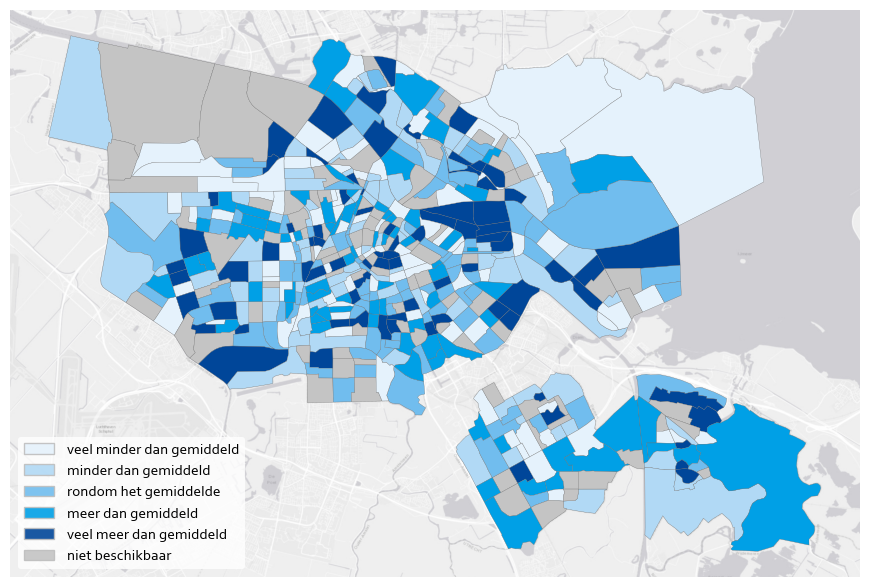

In [4]:
# Maak een plot voor de hele stad, op basis van de waarden in de kolom 'categorie'
plot_map(data, 'categorie', color_map_blue, path='figuren/stad.png')

### Stadsdelen

https://gitlab.com/os-amsterdam/datavisualisatie-onderzoek-en-statistiek/-/raw/main/geo/amsterdam//2022/stadsdelen-2022-geo.json


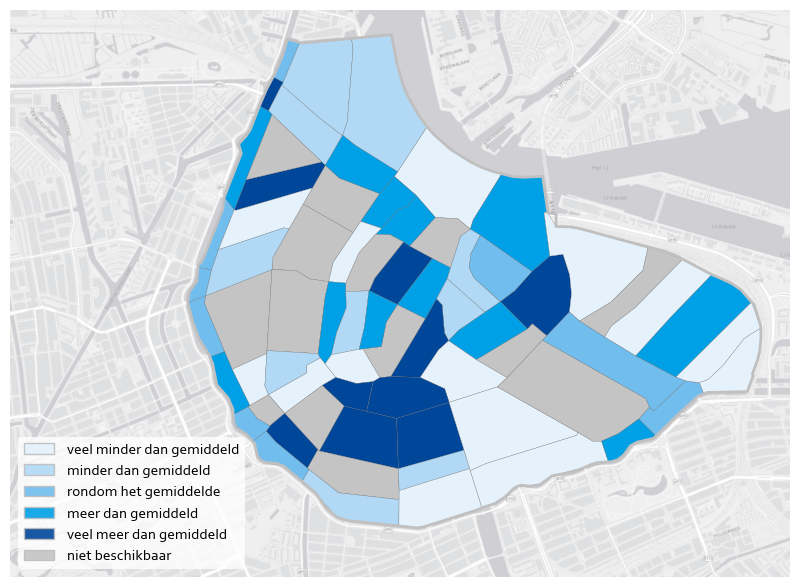

https://gitlab.com/os-amsterdam/datavisualisatie-onderzoek-en-statistiek/-/raw/main/geo/amsterdam//2022/stadsdelen-2022-geo.json


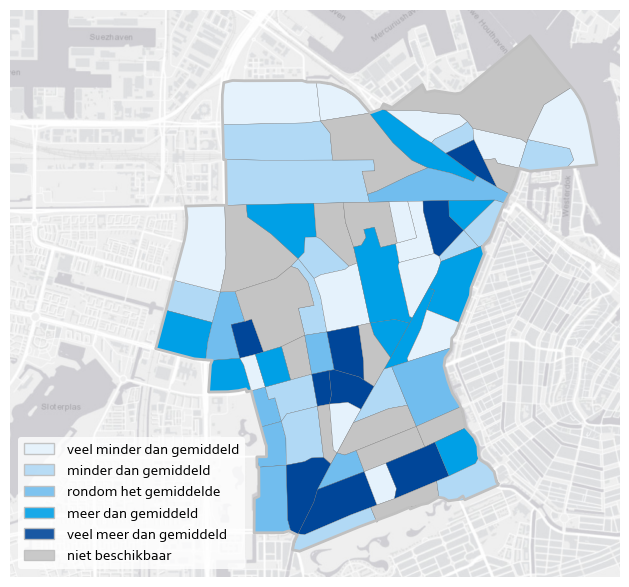

https://gitlab.com/os-amsterdam/datavisualisatie-onderzoek-en-statistiek/-/raw/main/geo/amsterdam//2022/stadsdelen-2022-geo.json


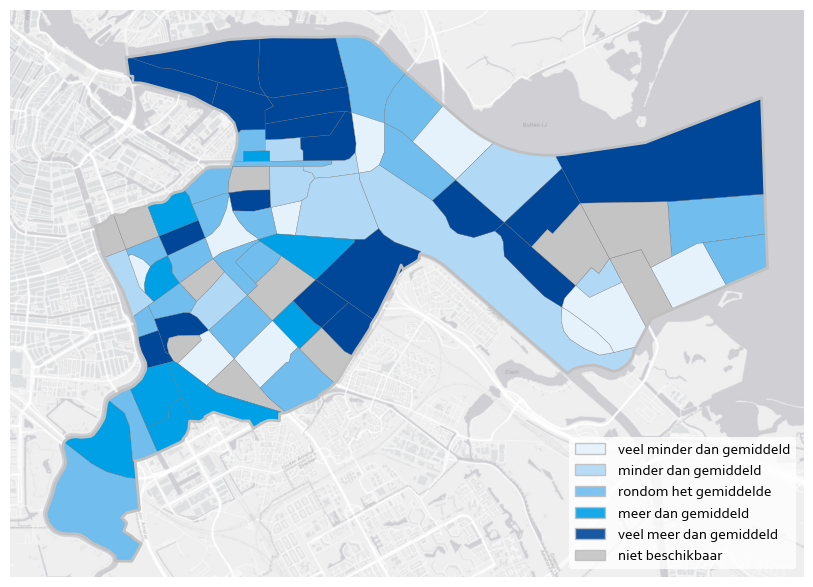

https://gitlab.com/os-amsterdam/datavisualisatie-onderzoek-en-statistiek/-/raw/main/geo/amsterdam//2022/stadsdelen-2022-geo.json


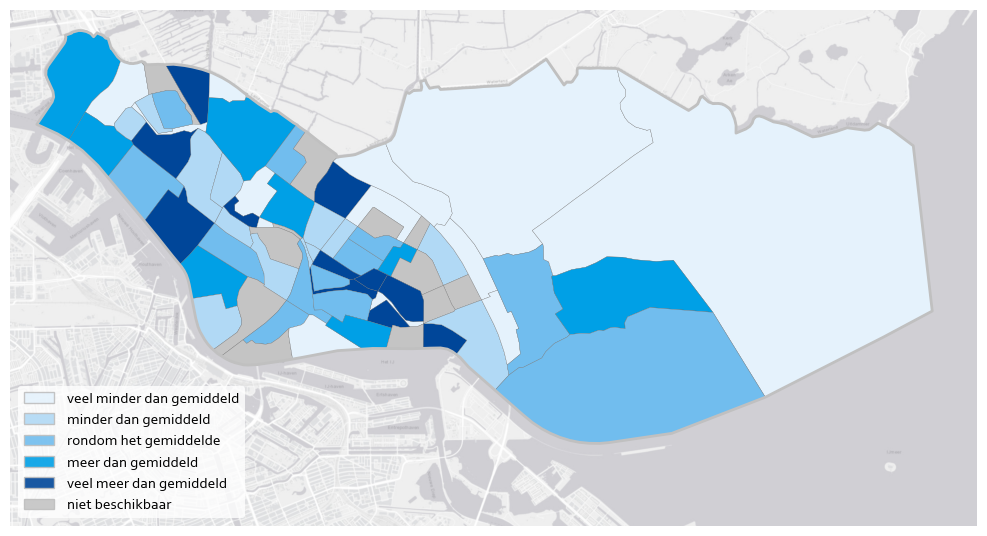

https://gitlab.com/os-amsterdam/datavisualisatie-onderzoek-en-statistiek/-/raw/main/geo/amsterdam//2022/stadsdelen-2022-geo.json


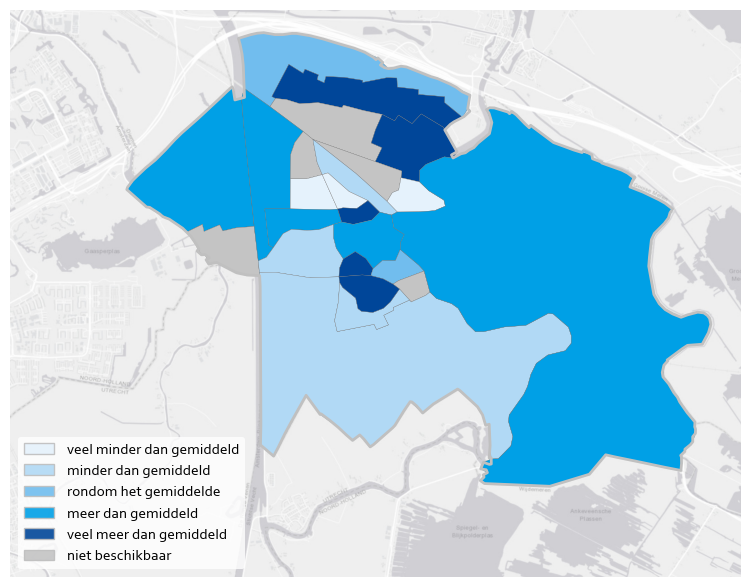

https://gitlab.com/os-amsterdam/datavisualisatie-onderzoek-en-statistiek/-/raw/main/geo/amsterdam//2022/stadsdelen-2022-geo.json


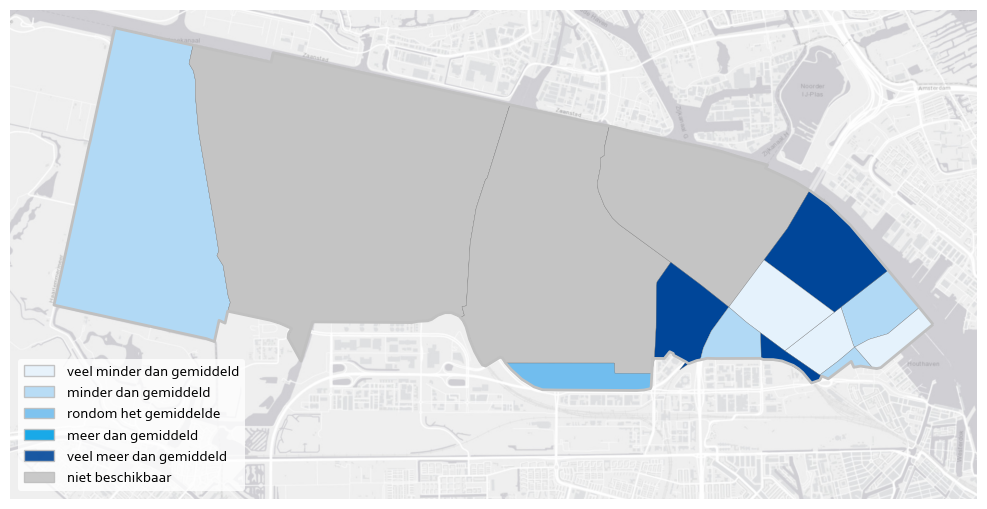

https://gitlab.com/os-amsterdam/datavisualisatie-onderzoek-en-statistiek/-/raw/main/geo/amsterdam//2022/stadsdelen-2022-geo.json


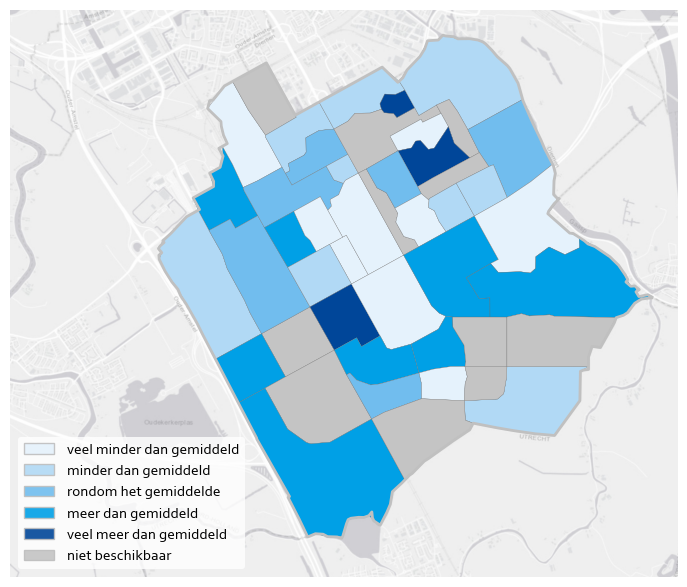

https://gitlab.com/os-amsterdam/datavisualisatie-onderzoek-en-statistiek/-/raw/main/geo/amsterdam//2022/stadsdelen-2022-geo.json


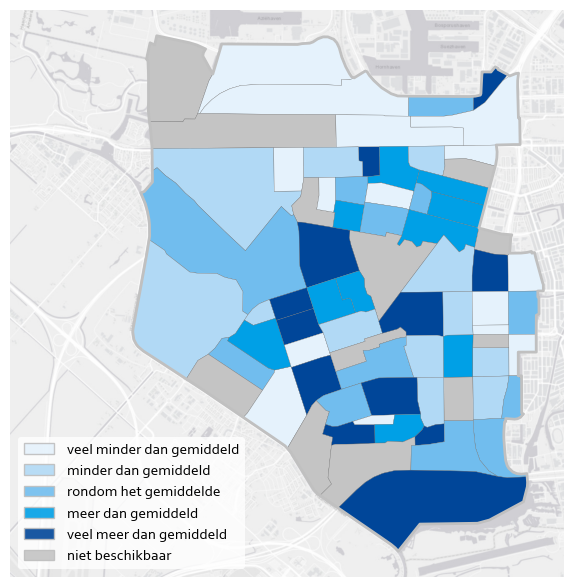

https://gitlab.com/os-amsterdam/datavisualisatie-onderzoek-en-statistiek/-/raw/main/geo/amsterdam//2022/stadsdelen-2022-geo.json


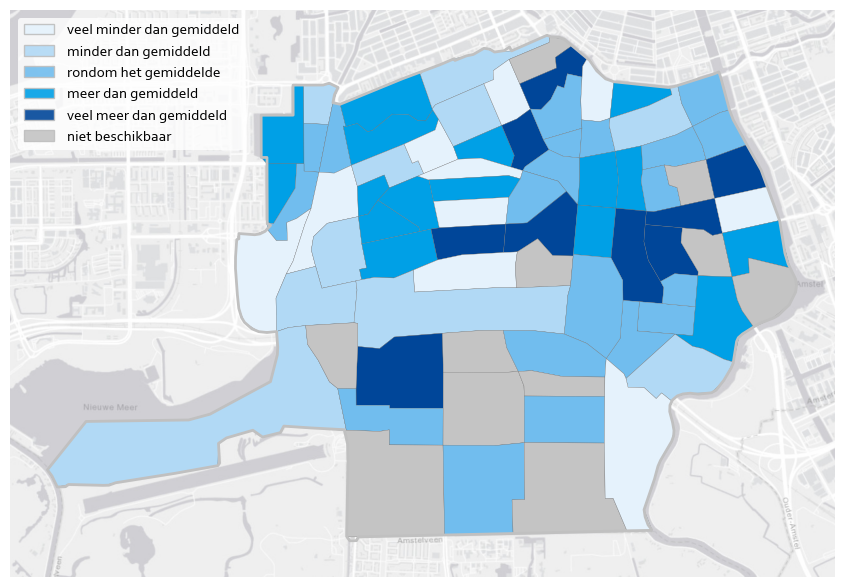

In [5]:
# Plot per stadsdeel, geef nu ook stadsdeelcode mee en de legendalocatie 
for stadsdeel in data["stadsdeelCode"].unique():
    plot_map(
        data,
        "categorie",
        color_map_blue,
        stadsdeel=stadsdeel,
        legend_loc=legend_loc[stadsdeel]['loc'],
        shift=legend_loc[stadsdeel]['shift'],
        path=f'figuren/stadsdeel_{stadsdeel}.png'
    )